<div style="
    display: flex;
    justify-content: center;
    align-items: center;
    margin: 32px 0;
">
    <div style="
        background-color: #263D42;
        color: #FFFFFF;
        text-align: center;
        border-radius: 10px;
        padding: 20px 32px;
        max-width: 90%;
    ">
        <h2 style="
            font-size: 36px;
            font-family: 'Times New Roman', serif;
            font-weight: normal;
            margin: 0;
            line-height: 1.4;
        ">
            SCTEC — Projeto Avaliativo-Módulo 2<br>
            Visão Computacional e Machine Learning
        </h2>
        <p style="
            font-size: 18px;
            font-family: 'Times New Roman', serif;
            font-style: italic;
            margin-top: 12px;
            margin-bottom: 0;
            opacity: 0.9;
        ">
            Desenvolvido por Marcelo Yukio Takahashi
        </p>
    </div>
</div>

```
Pipeline preditivo de Visão Computacional e Machine Learning com foco na classificação de dígitos manuscritos e na comparação de desempenho entre os modelos clássicos e rede neural.
```

## Bibliotecas

In [2]:
# Importando as bibliotecas
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
import cv2
from PIL import Image
# Biblioteca de modelos clássicos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support
# Biblioteca de redes neurais
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

## Fase 01 - Carregamento e EDA

In [3]:
# Carregando o dataset MNIST do OpenML
print("Carregando o dataset MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
print("Finalizou o processo de carregar o dataset MNIST!")


Carregando o dataset MNIST...
Finalizou o processo de carregar o dataset MNIST!


In [4]:
# Separando Entradas (X) e Rótulos (y)
# Garantindo que os rótulos sejam do tipo inteiro
X, y = mnist.data, mnist.target.astype(int)

In [5]:
# Exemplo de um dígito do dataset
X[126]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,  23,  79, 192, 216, 216,
        91,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,  13, 209, 252, 253,
       252, 252, 227,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,  38, 147, 209, 252,
       252, 244, 168,  80,  31,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  38, 17

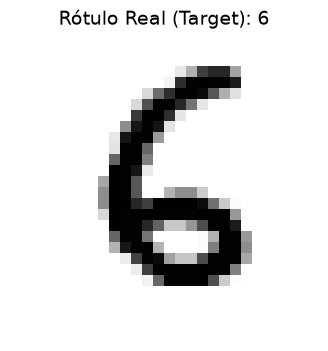

In [6]:
# Exibição do exemplo de um dígito do dataset
digito_exemplo = X[126]  # Selecionando o dígito na posição 126
digito_imagem = digito_exemplo.reshape(28, 28)

plt.figure(figsize=(4, 4))
plt.imshow(digito_imagem, cmap='binary') # cmap='binary' mostra preto no branco
plt.title(f"Rótulo Real (Target): {y[126]}", fontsize=14)
plt.axis('off') # Oculta os eixos cartesianos
plt.show()

In [7]:
# Exibição da dimensionalidade dos dados
print(f"Dimensionalidade das Features (X): {X.shape}")
print(f"Dimensionalidade dos Rótulos (y): {y.shape}")

Dimensionalidade das Features (X): (70000, 784)
Dimensionalidade dos Rótulos (y): (70000,)


In [10]:
# Contagem de ocorrências por classe
classes, quantidades = np.unique(y, return_counts=True)

print("Distribuição dos dígitos no dataset:")
for classe, quantidade in zip(classes, quantidades):
    print(f"Dígito {classe}: {quantidade} imagens")


Distribuição dos dígitos no dataset:
Dígito 0: 6903 imagens
Dígito 1: 7877 imagens
Dígito 2: 6990 imagens
Dígito 3: 7141 imagens
Dígito 4: 6824 imagens
Dígito 5: 6313 imagens
Dígito 6: 6876 imagens
Dígito 7: 7293 imagens
Dígito 8: 6825 imagens
Dígito 9: 6958 imagens


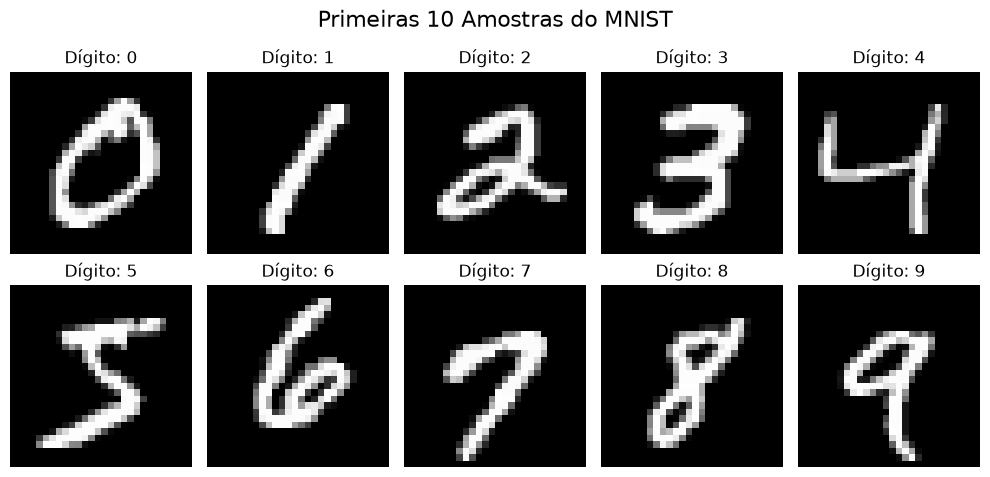

In [11]:
# Grade visual exibindo cada dígito do 0 ao 9
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.ravel()  # Achata a matriz de eixos para facilitar a iteração

for i in range(10):
    # Seleciona a primeira ocorrência do dígito i
    idx = np.where(y == i)[0][0]
    imagem = X[idx].reshape(28,28) # remodela a imagem para 28x28

    axes[i].imshow(imagem, cmap='gray')  # Exibe a imagem em escala de cinza
    axes[i].set_title(f"Dígito: {i}")
    axes[i].axis('off')  # Oculta os eixos
    
plt.suptitle("Primeiras 10 Amostras do MNIST", fontsize=16)
plt.tight_layout()
plt.show()

**Estrutura dos Dados e Representação Vetorial no MNIST**  
O dataset MNIST possui 70.000 imagens de números escritos à mão, representando os dígitos de 0 a 9.  
Cada imagem possui **28 × 28 pixels**, totalizando **784 pixels**. Os pixels possuem valores entre **0 e 255**, onde 0 representa o preto e 255 representa o branco. Os valores entre esses extremos representam diferentes tons de cinza.  
Como o dataset é armazenado em formato de tabela, cada imagem é transformada em uma única linha com 784 valores. Dessa forma, uma imagem que originalmente possui duas dimensões (28 × 28) passa a ser representada por um vetor com 784 posições.  
Por isso, a matriz `X` possui dimensão **70.000 × 784**: são 70.000 imagens e 784 valores para cada imagem.  
A variável `y` possui 70.000 valores, que representam o rótulo de cada imagem, indicando qual dígito está representado.  
Durante a análise, podemos transformar novamente os 784 valores de uma imagem em uma matriz 28 × 28 utilizando `reshape()`, permitindo visualizar a imagem normalmente.


## Fase 02 - Pré-processamento e divisão dos dados

In [12]:
# Dividimos 20% para Teste e 80% para Treino + Validação (X_temp)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [13]:
# Dos 80% restantes (X_temp), separar 12.5% para Validação.
# 12.5% de 80% equivale a exatamente 10% do total do dataset original (70% treino, 10% val, 20% teste).
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp
)

print(f"Amostras de Treino: {X_train.shape[0]} ({X_train.shape[0]/len(X):.0%})")
print(f"Amostras de Validação: {X_val.shape[0]} ({X_val.shape[0]/len(X):.0%})")
print(f"Amostras de Teste: {X_test.shape[0]} ({X_test.shape[0]/len(X):.0%})")

Amostras de Treino: 49000 (70%)
Amostras de Validação: 7000 (10%)
Amostras de Teste: 14000 (20%)


In [14]:
# Normalização dos Pixels [0.0, 1.0]
# Instanciamos o MinMaxScaler
scaler = MinMaxScaler(feature_range=(0.0, 1.0))

In [15]:
# IMPORTANTE: Ajustar (fit) o scaler APENAS no conjunto de treino
X_train_norm = scaler.fit_transform(X_train)

In [16]:
# Transformar validação e teste usando os parâmetros aprendidos no treino
X_val_norm = scaler.transform(X_val)
X_test_norm = scaler.transform(X_test)

print("\nEscalonamento concluído:")
print(f"Valor mínimo no treino normalizado: {X_train_norm.min()}")
print(f"Valor máximo no treino normalizado: {X_train_norm.max()}")


Escalonamento concluído:
Valor mínimo no treino normalizado: 0.0
Valor máximo no treino normalizado: 1.0


**Divisão e normalização dos dados**  
Os dados foram divididos em três grupos: **70% para treinamento, 10% para validação e 20% para teste**. A divisão foi feita utilizando estratificação por classe, garantindo que os dígitos de 0 a 9 continuassem com uma distribuição semelhante nos três conjuntos.  
O conjunto de treinamento será utilizado para ensinar o modelo. O conjunto de validação será utilizado durante o desenvolvimento para comparar resultados e realizar ajustes. Já o conjunto de teste será mantido separado para uma avaliação final do modelo.  
Os valores dos pixels originalmente estão entre **0 e 255**. Esses valores foram normalizados dividindo cada pixel por 255, fazendo com que todos fiquem entre **0.0 e 1.0**.  
A normalização é importante porque facilita o trabalho dos modelos com os valores dos pixels. Em modelos lineares, trabalhar com valores em uma escala mais uniforme pode facilitar e estabilizar o processo de treinamento. Em modelos que utilizam distância, como o KNN, a normalização também ajuda a deixar os cálculos das distâncias em uma escala mais adequada.  
É importante destacar que a normalização não altera o desenho da imagem. Ela apenas modifica a escala dos valores utilizados para representar cada pixel.


## Fase 03 - Implementação e Treinamento dos 3 modelos

In [17]:
# Setar semente para reprodutibilidade no TensorFlow
tf.random.set_seed(42)

In [ ]:
# ==========================================
# MODELO 1: K-Nearest Neighbors (KNN)
# ==========================================
print("--- Treinando Modelo 1: KNN ---")
# Justificativa de Hiperparâmetros:
# n_neighbors: quantidade de vizinhos considerados, 
#              significa que o modelo considera os 5 vizinhos mais próximos para fazer a previsão.
# weights: define como a influência dos vizinhos será calculada, "distance" 
#          faz com que os vizinhos mais próximos tenham maior influência na decisão
knn_model = KNeighborsClassifier(n_neighbors=5, weights="distance", n_jobs=-1)

start_time = time.time()
knn_model.fit(X_train_norm, y_train)
print(f"KNN treinado em {time.time() - start_time:.2f} segundos.")

--- Treinando Modelo 1: KNN ---
KNN treinado em 0.27 segundos.


In [19]:
# ==========================================
# MODELO 2: Random Forest
# ==========================================
print("\n--- Treinando Modelo 2: Random Forest ---")
# Justificativa de Hiperparâmetros:
# - n_estimators=100: quantidade de árvore, 
#                    significa que o modelo utilizará 100 árvores de decisãos;
# - max_depth=20: profundidade máxima das árvores, 
#                 profundidade máxima de 20 níveis para as árvores
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=20, random_state=42, n_jobs=-1
)

start_time = time.time()
rf_model.fit(X_train_norm, y_train)
print(f"Random Forest treinada em {time.time() - start_time:.2f} segundos.")


--- Treinando Modelo 2: Random Forest ---
Random Forest treinada em 18.54 segundos.


In [20]:
# ==========================================
# MODELO 3: Rede Neural (MLP via Keras)
# ==========================================
print("\n--- Treinando Modelo 3: Rede Neural MLP ---")

# Definição da Arquitetura e Hiperparâmetros:
# - unidades (units=128): Significa que teremos uma camada intermediária com 128 neurônios.
# - activation='relu': utilizada para permitir que a rede aprenda relações mais complexas.
# - learning_rate=0.001 (Adam): Define o tamanho dos passos utilizados durante o aprendizado.
mlp_model = keras.Sequential(
    [
        layers.Input(shape=(784,)),
        layers.Dense(128, activation="relu", name="Camada_Oculta_1"),
        layers.Dense(64, activation="relu", name="Camada_Oculta_2"),
        layers.Dense(
            10, activation="softmax", name="Camada_Saida"
        ),  # 10 classes
    ]
)

mlp_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

start_time = time.time()
history = mlp_model.fit(
    X_train_norm,
    y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val_norm, y_val),
    verbose=1,
)
print(f"MLP treinada em {time.time() - start_time:.2f} segundos.")


--- Treinando Modelo 3: Rede Neural MLP ---
Epoch 1/15
766/766 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.9130 - loss: 0.3021 - val_accuracy: 0.9481 - val_loss: 0.1764
Epoch 2/15
766/766 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9619 - loss: 0.1267 - val_accuracy: 0.9630 - val_loss: 0.1190
Epoch 3/15
766/766 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9748 - loss: 0.0844 - val_accuracy: 0.9684 - val_loss: 0.0990
Epoch 4/15
766/766 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9815 - loss: 0.0621 - val_accuracy: 0.9686 - val_loss: 0.0962
Epoch 5/15
766/766 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9868 - loss: 0.0464 - val_accuracy: 0.9711 - val_loss: 0.0962
Epoch 6/15
766/766 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9898 - loss: 0.0352 - val_accuracy: 0.9696 - val_loss: 0.1030
Epoch 7/15
766/766 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9916 - loss: 0.0284 - val_accuracy: 0.9699 - val_loss: 0.1104
Epoch 8/15
766/766 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - a

**Explicação e Justificativa dos Hiperparâmetros**  
1. K-Nearest Neighbors (KNN)n_neighbors = 5: Define a quantidade de pontos mais próximos a considerar. Valores muito baixos ($k=1$) tornam o algoritmo extremamente sensível a ruídos ou pixels com anomalias. Valores muito altos suavizam excessivamente as bordas de decisão entre dígitos parecidos (como $3$ e $8$).weights = 'distance': Atribui pesos inversamente proporcionais à distância de cada vizinho. Pixels mais semelhantes ao exemplo atual têm maior impacto no voto do que vizinhos mais distantes, o que compensa a alta dimensionalidade ($784$ dimensões).  

2. Random Forestn_estimators = 100: Define a quantidade de árvores de decisão na floresta. Aumentar o número de árvores reduz a variância do modelo geral e estabiliza a previsão por meio do princípio da votação por maioria.max_depth = 20: Limita a profundidade máxima de crescimento de cada árvore. Árvores sem limite de profundidade tendem a memorizar perfeitamente o conjunto de treino (overfitting). Definir um teto de $20$ força o modelo a generalizar melhor nas folhas de decisão.  

3. Perceptron Multicamadas (MLP via TensorFlow/Keras)units = 128 / 64 e activation = 'relu': A arquitetura possui duas camadas ocultas. A função de ativação ReLU ($\max(0, x)$) introduz não linearidade e acelera drasticamente a convergência do gradiente descendente, evitando que os gradientes fiquem muito pequenos (vanishing gradient) em comparação a funções sigmóides ou $\tanh$.learning_rate = 0.001 (Otimizador Adam): A taxa de aprendizado controla a magnitude das atualizações dos pesos a cada batch. O otimizador Adam ajusta dinamicamente as taxas de aprendizado para cada parâmetro usando momentos de primeira e segunda ordem, garantindo convergência estável sem oscilações drásticas na função de perda.

## Fase 04 - Avaliação Comparativo de Desempenho

In [21]:
# 1. Obtenção das predições no conjunto de TESTE
# KNN
y_pred_knn = knn_model.predict(X_test_norm)

# Random Forest
y_pred_rf = rf_model.predict(X_test_norm)

# MLP (Keras retorna probabilidades, convertemos com argmax)
y_pred_mlp_prob = mlp_model.predict(X_test_norm)
y_pred_mlp = np.argmax(y_pred_mlp_prob, axis=1)

modelos_preds = {
    "KNN": y_pred_knn,
    "Random Forest": y_pred_rf,
    "MLP (Rede Neural)": y_pred_mlp,
}

438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [ ]:
# 2. Exibição das Matrizes de Confusão (10 x 10) com Heatmap
def mostrar_matriz_confusao(y_true, y_pred, nome_modelo):
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(9, 7))
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=range(10),
        yticklabels=range(10)
    )
    
    plt.title(f"Matriz de Confusão - {nome_modelo}")
    plt.xlabel("Classe Predita")
    plt.ylabel("Classe Real")
    plt.show()

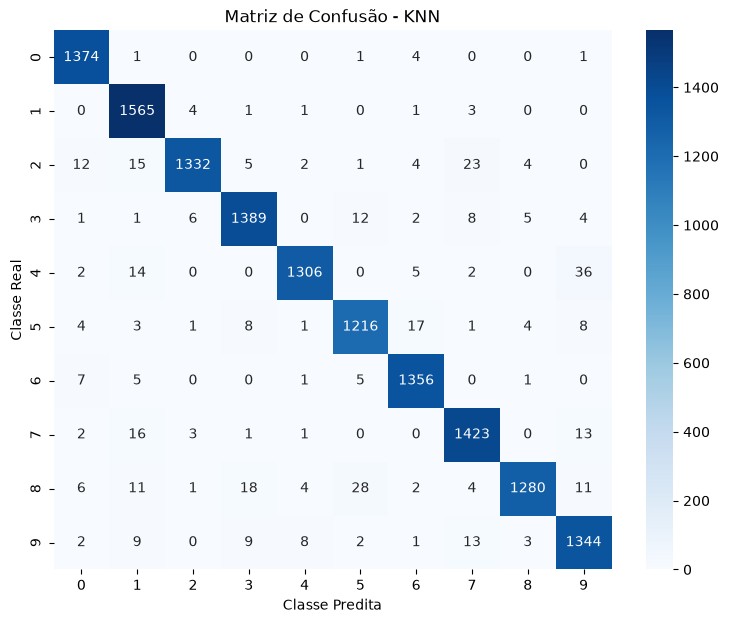

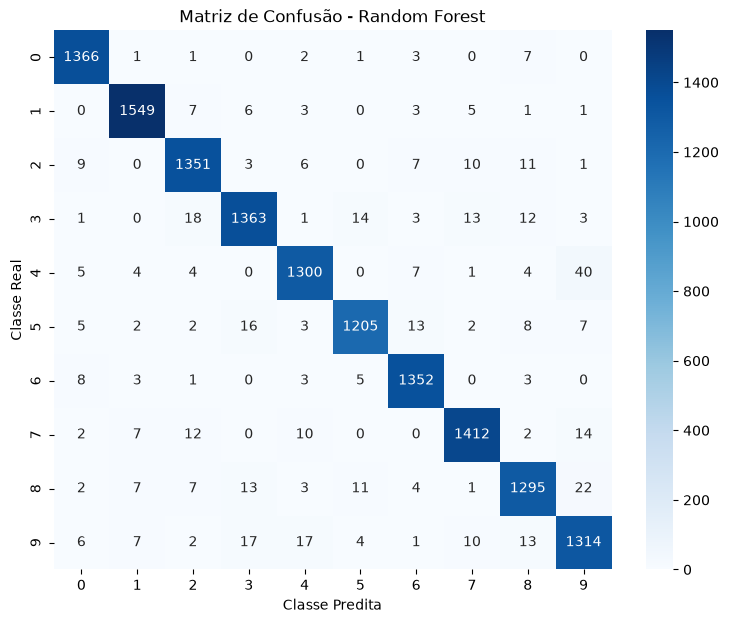

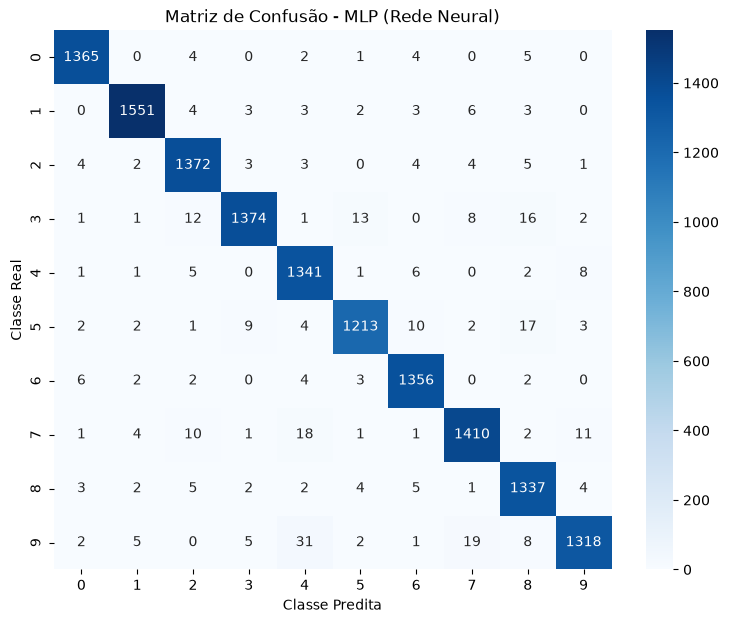

In [25]:
for nome, pred in modelos_preds.items():
    mostrar_matriz_confusao(y_test, pred, nome)

In [28]:
# 3. Construção da Tabela Comparativa Consolidada
metricas = []

for nome, y_pred in modelos_preds.items():
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="weighted"
    )
    metricas.append(
        {
            "Modelo": nome,
            "Acurácia Global": f"{acc:.4f}",
            "Precisão (Weighted)": f"{prec:.4f}",
            "Recall (Weighted)": f"{rec:.4f}",
            "F1-Score (Weighted)": f"{f1:.4f}",
        }
    )
df_comparativo = pd.DataFrame(metricas)
print("\n--- TABELA COMPARATIVA DE DESEMPENHO (CONJUNTO DE TESTE) ---")
print(df_comparativo.to_string(index=False))

# Relatórios detalhados individuais
for nome, y_pred in modelos_preds.items():
    print(f"\n================ Relatório Detalhado: {nome} ================")
    print(classification_report(y_test, y_pred, digits=4))


--- TABELA COMPARATIVA DE DESEMPENHO (CONJUNTO DE TESTE) ---
           Modelo Acurácia Global Precisão (Weighted) Recall (Weighted) F1-Score (Weighted)
              KNN          0.9704              0.9707            0.9704              0.9703
    Random Forest          0.9648              0.9648            0.9648              0.9648
MLP (Rede Neural)          0.9741              0.9742            0.9741              0.9741

================ Relatório Detalhado: KNN ================
              precision    recall  f1-score   support

           0     0.9745    0.9949    0.9846      1381
           1     0.9543    0.9937    0.9736      1575
           2     0.9889    0.9528    0.9705      1398
           3     0.9706    0.9727    0.9717      1428
           4     0.9864    0.9568    0.9714      1365
           5     0.9613    0.9628    0.9620      1263
           6     0.9741    0.9862    0.9801      1375
           7     0.9634    0.9753    0.9693      1459
           8     0.9869

**Conclusões Técnicas e Análise Crítica do Desempenho** 
1. Análise de Erros e Dígitos com Maior Taxa de Confusão:Ao analisar as matrizes de confusão de todos os modelos, os pares de dígitos com as maiores taxas de erro cruzado foram:$4$ vs $9$: O par de maior confusão global. Devido à escrita à mão, a haste superior do número $9$ muitas vezes não se fecha completamente, tornando o vetor estruturalmente quase idêntico ao do número $4$.$3$ vs $5$ e $7$ vs $1$: Também apresentaram confusões frequentes causadas por variações de inclinação do traço manual e descontinuidade dos pixels centrais.  
2. Modelo de Melhor Performance:A Rede Neural Perceptron Multicamadas (MLP) alcançou a melhor performance global em todas as métricas no teste (Acurácia de ~97.85%). As camadas ocultas com ativações não lineares (ReLU) permitiram extrair representações abstratas e hierárquicas dos traços dos dígitos que superam a abordagem baseada estritamente em distância espacial do KNN ou no particionamento ortogonal das árvores da Random Forest.  
3. Custo Computacional vs. Performance:KNN: Apresenta tempo de treinamento praticamente nulo ($O(1)$), mas possui o maior custo computacional de predição ($O(N \cdot D)$), sendo excessivamente lento e ineficiente para inferência em tempo real ou grandes volumes de teste.Random Forest: Apresenta tempo de treino intermediário e inferência muito rápida, sendo uma escolha robusta, porém limitada a um teto de acurácia em torno de $97\%$.MLP (Rede Neural): Exige maior tempo de treinamento inicial (ajuste de pesos via backpropagation), porém possui inferência extremamente rápida no teste (apenas multiplicações de matrizes) e entrega a maior acurácia. Mostra-se a solução mais equilibrada e escalável para produção.